In [2]:
import pandas as pd
import plotly.express as px

df = px.data.gapminder()

print(df.head())

       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


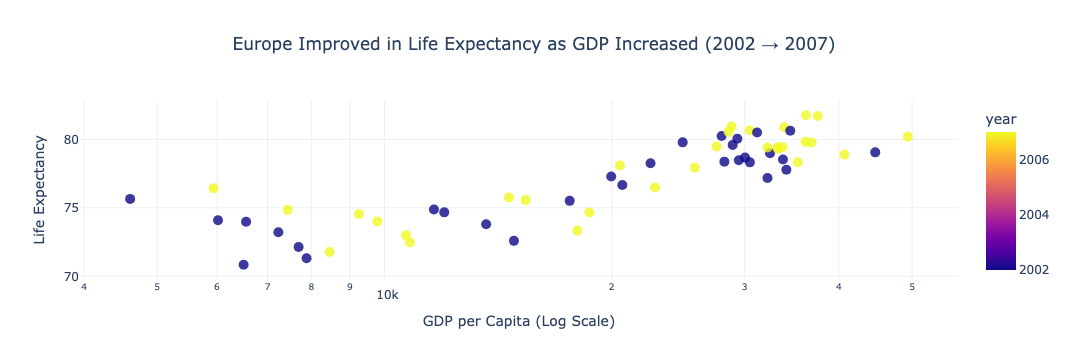

In [3]:

df_task1 = df.loc[
    (df['continent'] == 'Europe') &
    (df['year'].isin([2002, 2007]))
]

fig1 = px.scatter(
    df_task1,
    x='gdpPercap',
    y='lifeExp',
    color='year',
    hover_name='country',
    log_x=True,
    title='Europe Improved in Life Expectancy as GDP Increased (2002 → 2007)',
    labels={
        'gdpPercap': 'GDP per Capita (Log Scale)',
        'lifeExp': 'Life Expectancy'
    },
    color_discrete_sequence=['#4C78A8', '#F58518']
)

fig1.update_traces(marker=dict(size=10, opacity=0.8))

fig1.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig1.show()

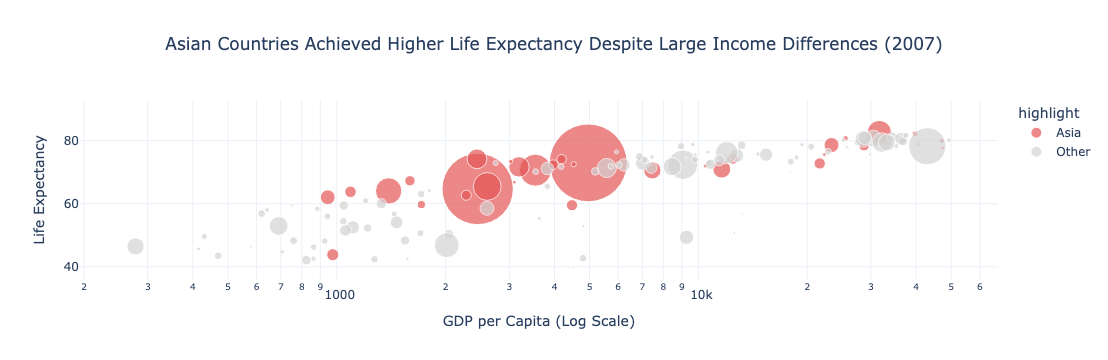

In [4]:

df_2007 = df.loc[df['year'] == 2007].copy()


highlight_continent = 'Asia'


df_2007['highlight'] = df_2007['continent'].apply(
    lambda x: highlight_continent if x == highlight_continent else 'Other'
)


fig2 = px.scatter(
    df_2007,
    x='gdpPercap',
    y='lifeExp',
    size='pop',
    color='highlight',
    hover_name='country',
    log_x=True,          
    size_max=55,        
    title='Asian Countries Achieved Higher Life Expectancy Despite Large Income Differences (2007)',
    
    labels={
        'gdpPercap': 'GDP per Capita (Log Scale)',
        'lifeExp': 'Life Expectancy'
    },

    color_discrete_map={
        'Asia': '#E45756',
        'Other': 'lightgrey'
    }
)


fig2.add_annotation(
    x=5000,
    y=78,
    text='Many Asian countries reached high life expectancy<br>without the highest GDP levels.',
    showarrow=True,
    arrowhead=2
)


fig2.update_layout(
    template='plotly_white',
    title_x=0.5
)

fig2.show()